# Correlated errors-in-variables fit

This example fits a quadratic curve to synthetic data with uncertainty in both `x` and `y`. The full joint covariance, including x/y correlations, is retained.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

import latan
import latan.plot as lplt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Synthetic primary samples

Generate random synthetic data following the relationship $y(x) = p_0\,(x-p_1)^2 + p_2$, with
statistical errors in both $x$ and $y$. The generated samples are first processed into a
`CorrelatedData` object, `joint`, which stores correlations between all $x$ and $y$ measurements. This object is then used to initialize a `XYData` object, which identifies components of `joint` as $x$ or $y$ coordinates.

In [2]:
rng = np.random.default_rng(20260717)
n_points = 25
n_samples = 200
x_true = np.linspace(-2.0, 2.0, n_points)
p_true = np.array([1.7, 0.5, -1.3])
y_true = p_true[0] * (x_true - p_true[1]) ** 2 + p_true[2]

distance = np.abs(np.subtract.outer(x_true, x_true))
point_correlation = np.exp(-distance / 4)
variance_scale = 50.0
c_xx = variance_scale * 0.020 * point_correlation
c_yy = variance_scale * 0.240 * point_correlation
c_xy = variance_scale * 0.035 * point_correlation
sample_covariance = np.block([[c_xx, c_xy], [c_xy.T, c_yy]])
noise = rng.multivariate_normal(
    np.zeros(2 * n_points), sample_covariance, size=n_samples
)
x_samples = x_true + noise[:, :n_points]
y_samples = y_true + noise[:, n_points:]

joint = latan.CorrelatedData.from_samples([x_samples, y_samples])
xy_data = latan.XYData(joint, x=[0], y_indices=[1], x_names=["x"], y_names=["y"])
x_observed = xy_data.x()
y_observed = xy_data.y()
x_error = np.sqrt(np.diag(joint.cov(0, 0)))
y_error = np.sqrt(np.diag(joint.cov(1, 1)))

Plot data and covariance matrix.

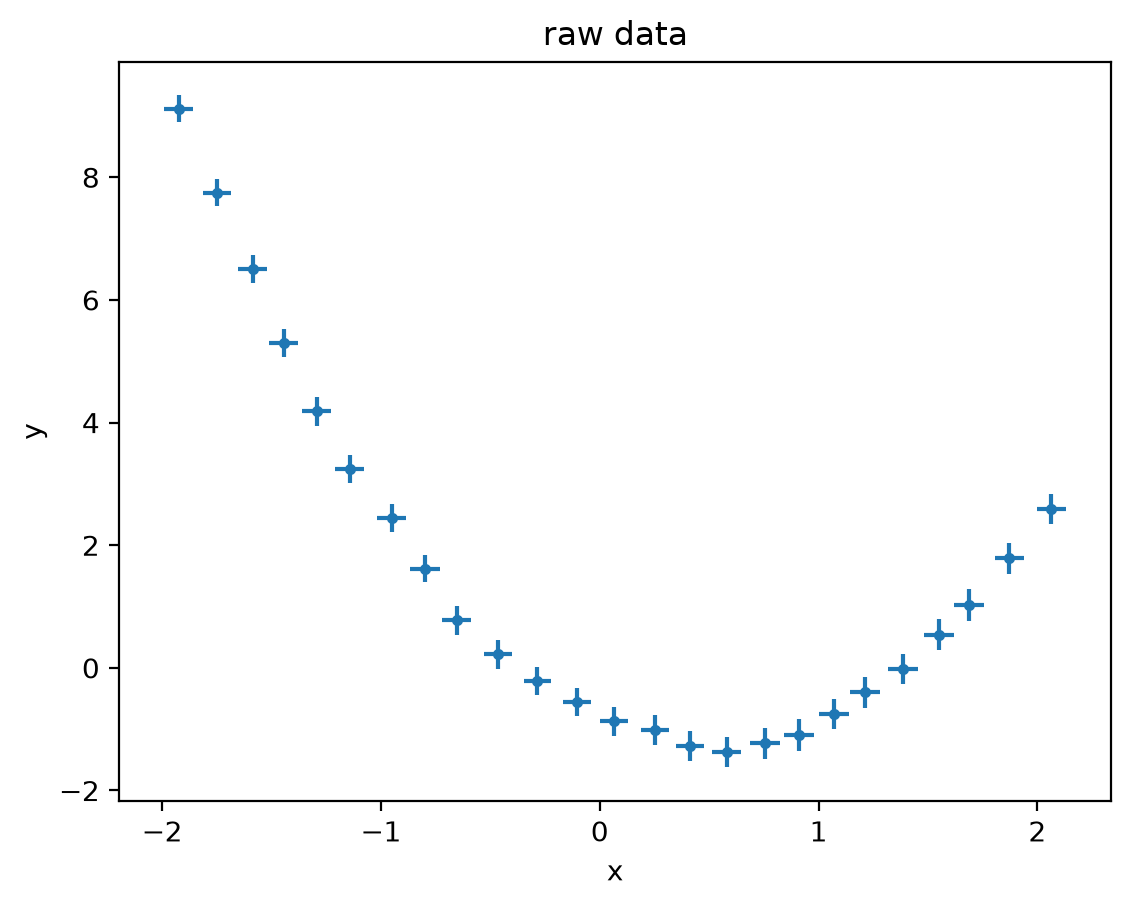

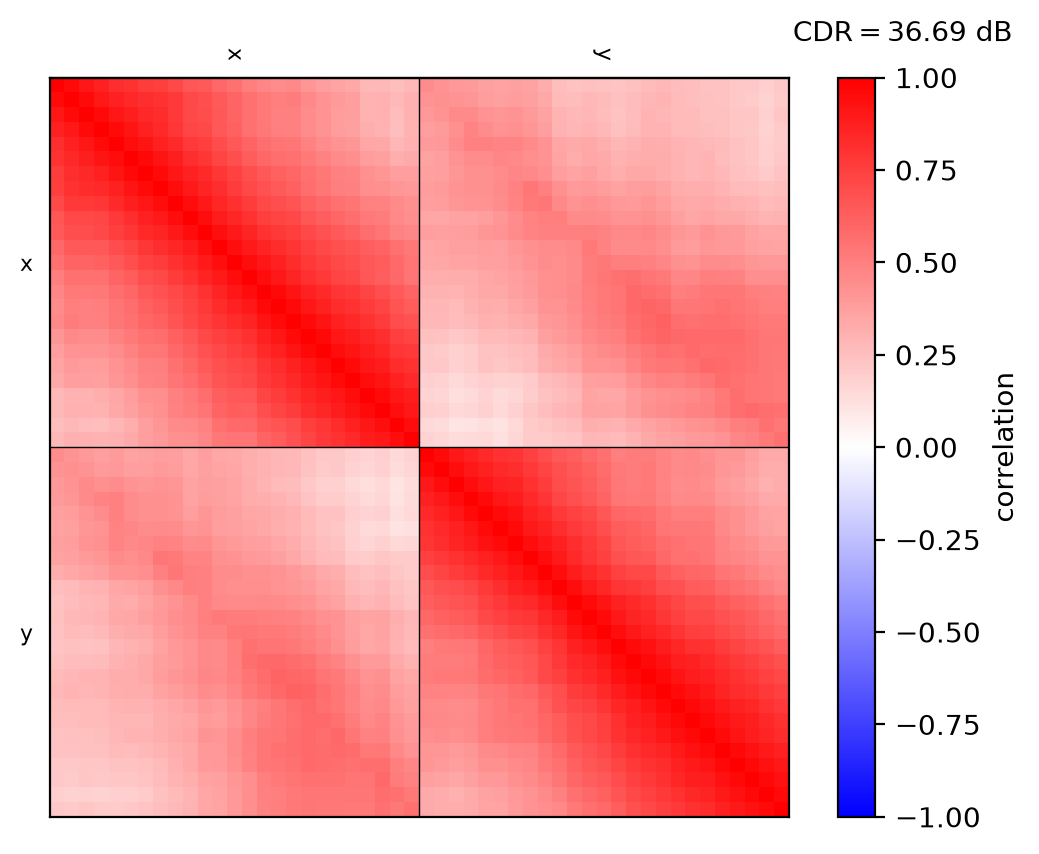

In [3]:
plt.errorbar(x_observed, y_observed, xerr=x_error, yerr=y_error, fmt=".")
plt.xlabel("x")
plt.ylabel("y")
plt.title("raw data")
plt.show()
lplt.xy_correlations(xy_data)
plt.show()

## Data fit

The data can then be fit to a model using a $\chi^2$ minimization, taking all correlations
into account. For each data point with an inexact $x$ coordinate, a latent parameter $\xi$
is introduced to allow $x$ to fluctuate within its uncertainty. Explicitly, in the simplified
case of uncorrelated data, the total $\chi^2$ function is

$$
\chi^2(p,\xi)=\sum_j \frac{[f(\xi_j;p)-y_j]^2}{\sigma_{y,j}^2}
+\sum_j \frac{(\xi_j-x_j)^2}{\sigma_{x,j}^2}\,,
$$

where $p$ are the model parameters; $x_j$ and $y_j$ are the data; $\sigma_{x,j}^2$ and $\sigma_{y,j}^2$ are their respective variances; and $\xi_j$ are the latent parameters.

The fitted points can be selected using the `include` and `exclude` parameters. Both parameters are interpreted as closed intervals. Points first satisfy `include`, then matching `exclude` points are removed.

In [4]:
def quadratic(x, p):
    return p[..., 0] * (x[..., 0] - p[..., 1]) ** 2 + p[..., 2]


include = [(None, 1.7)]
exclude = [(-0.25, 0.25)]
model = latan.Model(quadratic, n_var=1, n_par=3)
p0 = np.array([1.0, 1.0, 1.0])
fit_result = latan.fit(xy_data, model, p0, include=include, exclude=exclude)
p_fit = fit_result.model_parameters
xi_fit = fit_result.latent_parameters
selected = xy_data.point_mask(include, exclude)
display(fit_result)

FitResult(parameters=array([ 1.73252458,  0.5590174 , -1.19286978, -1.89161608, -1.72124508,
       -1.55627435, -1.39670945, -1.23347064, -1.07905784, -0.91411058,
       -0.75533587, -0.58396517, -0.4117366 , -0.24952857,  0.23771528,
        0.42806361,  0.61451266,  0.79463316,  0.96244216,  1.12139105,
        1.2635425 ,  1.42023907,  1.59192234,  1.71927901]), chi2=21.87348879527233, dof=18, p_value=0.23765030221263217, cdr=np.float64(35.52115571944816), n_model_parameters=3, parameter_names=('p_0', 'p_1', 'p_2'))

## Diagnostics

The first panel distinguishes selected and excluded measurements. The second compares the fitted latent $x$ values with the observed $x$ values. The last panel shows normalized $y$ residuals.

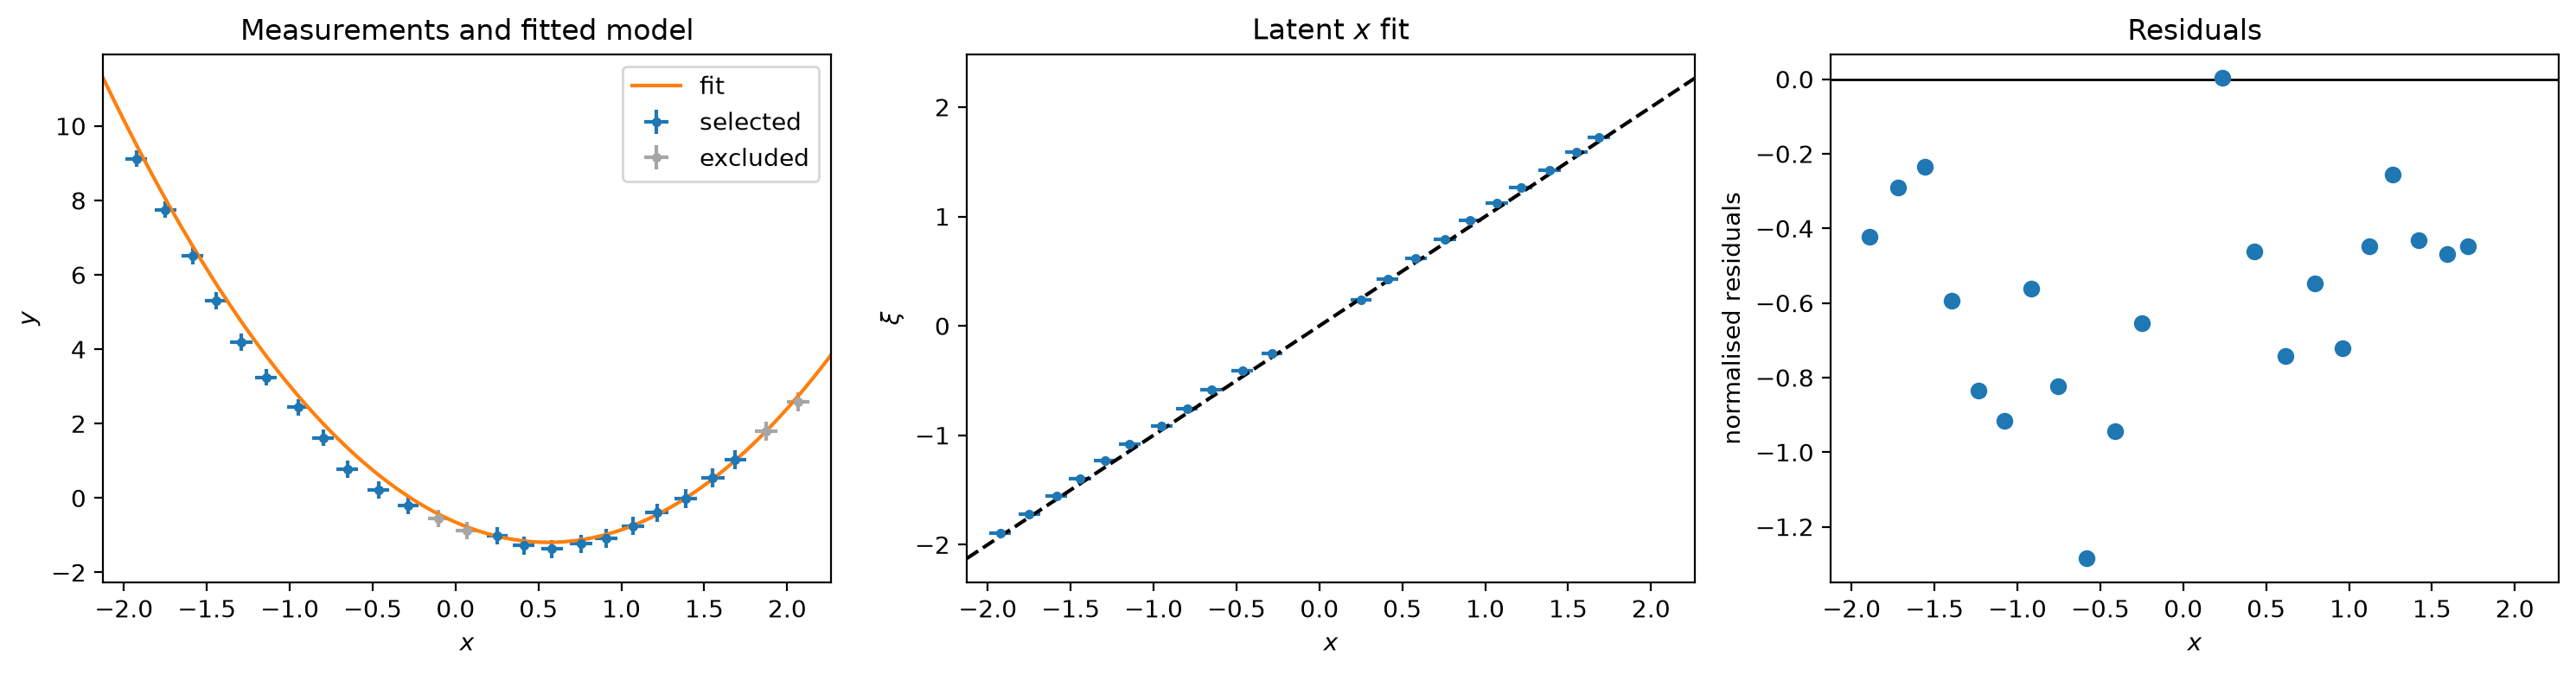

In [5]:
excluded = ~selected
plt.figure(figsize=(15, 4))
x_min = x_observed.min() - 0.2
x_max = x_observed.max() + 0.2
grid = np.linspace(x_min, x_max, 300)
plt.subplot(1, 3, 1)
plt.errorbar(
    x_observed[selected],
    y_observed[selected],
    xerr=x_error[selected],
    yerr=y_error[selected],
    fmt=".",
    label="selected",
)
plt.errorbar(
    x_observed[excluded],
    y_observed[excluded],
    xerr=x_error[excluded],
    yerr=y_error[excluded],
    fmt=".",
    color="0.65",
    label="excluded",
)
plt.plot(grid, model(grid[:, None], p_fit), label="fit")
plt.xlim(x_min, x_max)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Measurements and fitted model")
plt.legend()
plt.subplot(1, 3, 2)
plt.errorbar(x_observed[selected], xi_fit, xerr=x_error[selected], fmt=".")
limits = [min(x_min, xi_fit.min()), max(x_max, xi_fit.max())]
plt.plot(limits, limits, "k--")
plt.xlim(x_min, x_max)
plt.xlabel("$x$")
plt.ylabel(r"$\xi$")
plt.title("Latent $x$ fit")
marginal_pulls = (y_observed[selected] - model(xi_fit[:, None], p_fit)) / y_error[
    selected
]
plt.subplot(1, 3, 3)
plt.axhline(0.0, color="k", lw=1)
plt.plot(xi_fit, marginal_pulls, "o")
plt.xlim(x_min, x_max)
plt.xlabel("$x$")
plt.ylabel("normalised residuals")
plt.title("Residuals")
plt.tight_layout()
plt.show()

## Bootstrap fit

The `fit` function can use bootstrap samples to estimate fit-parameter uncertainties.
The covariance matrix is from the bootstrap samples and remains fixed for every fit. The means are then taken from the corresponding bootstrap sample. Latan automatically displays the resulting uncertainties in the fit summary, and the `workers` parameter can parallelize the fits over samples.

In [6]:
n_bootstrap = 1000
bootstrap = latan.NonparametricBootstrap(seed=20260718)
bootstrap_data = [
    bootstrap.sample(x_samples, n_bootstrap),
    bootstrap.sample(y_samples, n_bootstrap),
]
bootstrap_joint = latan.CorrelatedData.from_bootstrap(bootstrap_data)
bootstrap_xy_data = latan.XYData(
    bootstrap_joint,
    x=[0],
    y_indices=[1],
    x_names=["x"],
    y_names=["y"],
)
bootstrap_result = latan.fit(
    bootstrap_xy_data,
    model,
    p_fit,
    include=include,
    exclude=exclude,
    workers=4,
)
display(bootstrap_result)
p_bootstrap = bootstrap_result.model_parameters

FitResult(parameters=BootstrapArray([[ 1.75103591,  0.56134938, -1.21481619, ...,  1.43438081,
                  1.59974036,  1.72741539],
                [ 1.72212458,  0.61307651, -1.20030723, ...,  1.50329416,
                  1.68461578,  1.83718543],
                [ 1.76453109,  0.51253588, -1.33914985, ...,  1.42615673,
                  1.59926925,  1.73136693],
                ...,
                [ 1.7428701 ,  0.59677584, -1.36591111, ...,  1.51962656,
                  1.68441627,  1.81329089],
                [ 1.74700244,  0.49847436, -1.41790203, ...,  1.37974905,
                  1.52357916,  1.66885658],
                [ 1.72691459,  0.60192361, -1.20066639, ...,  1.48888256,
                  1.66028346,  1.76706642]], shape=(1001, 24)), chi2=21.902290182017857, dof=18, p_value=0.23635204955255676, cdr=np.float64(35.60557722390265), n_model_parameters=3, parameter_names=('p_0', 'p_1', 'p_2'))

Plot of fitted data with $1\sigma$ prediction band.

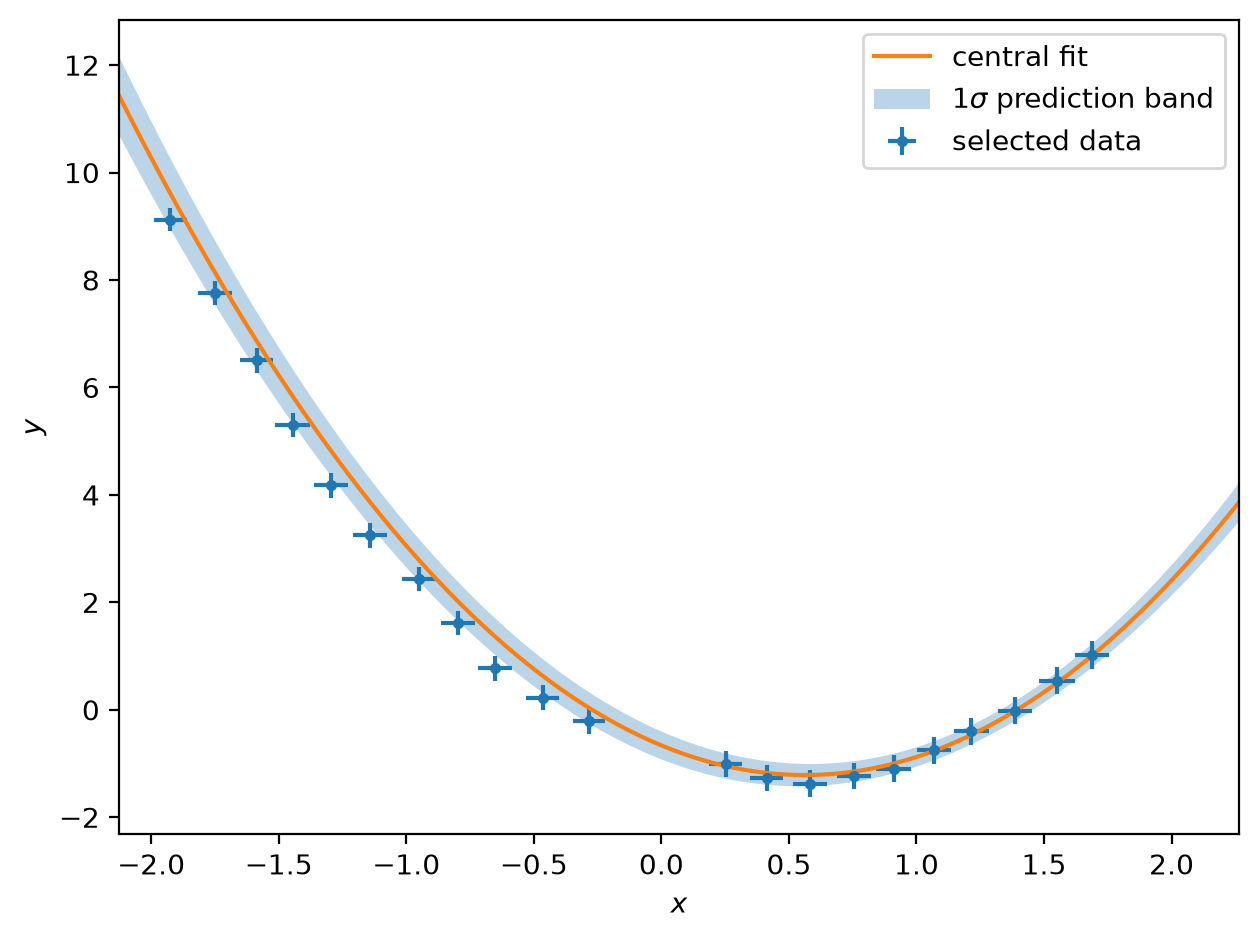

In [7]:
model_bootstrap = model.bootstrap(grid[:, None], p_bootstrap)
model_error = model_bootstrap.error()
plt.errorbar(
    x_observed[selected],
    y_observed[selected],
    xerr=x_error[selected],
    yerr=y_error[selected],
    fmt=".",
    label="selected data",
)
plt.plot(grid, model_bootstrap.central, label="central fit")
plt.fill_between(
    grid,
    model_bootstrap.central - model_error,
    model_bootstrap.central + model_error,
    alpha=0.3,
    label=r"$1\sigma$ prediction band",
)
plt.xlim(x_min, x_max)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend()
plt.tight_layout()
plt.show()